In [6]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

from scipy.optimize import curve_fit

import dexplore as dx 
import xarray as xr
import os
import sys
import glob
import re
from pathlib import Path

sys.path.append(os.path.abspath("steele-lab-analysis-functions"))
import analysis_functions.core as af
from analysis_functions.users.pacome._format_data_xarray import format_data_xarray

from cavity_analysis import cavity_analysis
from cavity_theory import cavity_modes

model = af.ComplexCircle()

In [7]:
dx.refresh_bokeh()

Loading BokehJS ...

In [8]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/full_process_0001'
#base_folder = '/home/jovyan/BACKUP/Pacome/full_process_0001'

In [9]:
fc = 9.30154207e+09
fm = 1.21e+06 + 881

In [11]:
file_folder = '2026-06-25_12.01.24_0056_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

source = format_data_xarray(data, tool='SA', translator=translator)

file_folder = '2026-06-25_12.02.30_0057_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

cavity = format_data_xarray(data, tool='SA', translator=translator)

file_folder = '2026-06-25_12.08.55_0058_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

background = format_data_xarray(data, tool='SA', translator=translator)

IndexError: list index out of range

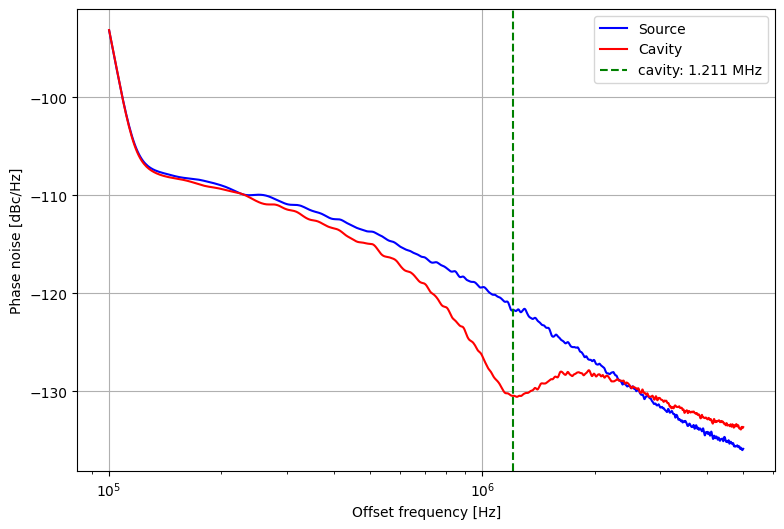

In [10]:
f0 = source.freq.values[np.argmax(source.spect.values)]

window = slice(f0 + 1e-4, source.freq.values[-1])
_source = source.sel(freq=window)
_cavity = cavity.sel(freq=window)

dBmmax_source = np.max(source.spect.values)
dBmmax_cavity = np.max(cavity.spect.values)
bandwidth = 51e+03

dBc_source = np.array(_source.spect.values) - dBmmax_source - 10*np.log10(bandwidth)
dBc_cavity = np.array(_cavity.spect.values) - dBmmax_cavity - 10*np.log10(bandwidth)

plt.figure(figsize=(9,6))
plt.semilogx((np.array(_source.freq.values) - f0)*1e+09, dBc_source, color='blue', label='Source')
plt.semilogx((np.array(_cavity.freq.values) - f0)*1e+09, dBc_cavity, color='red', label='Cavity')
plt.axvline(fm, color='green', linestyle='--', label=f'cavity: {fm*1e-6:.3f} MHz')

plt.axhline(dBc_cavity[np.where()])

plt.xlabel('Offset frequency [Hz]')
plt.ylabel('Phase noise [dBc/Hz]')
plt.legend()
plt.grid(True)
plt.show()

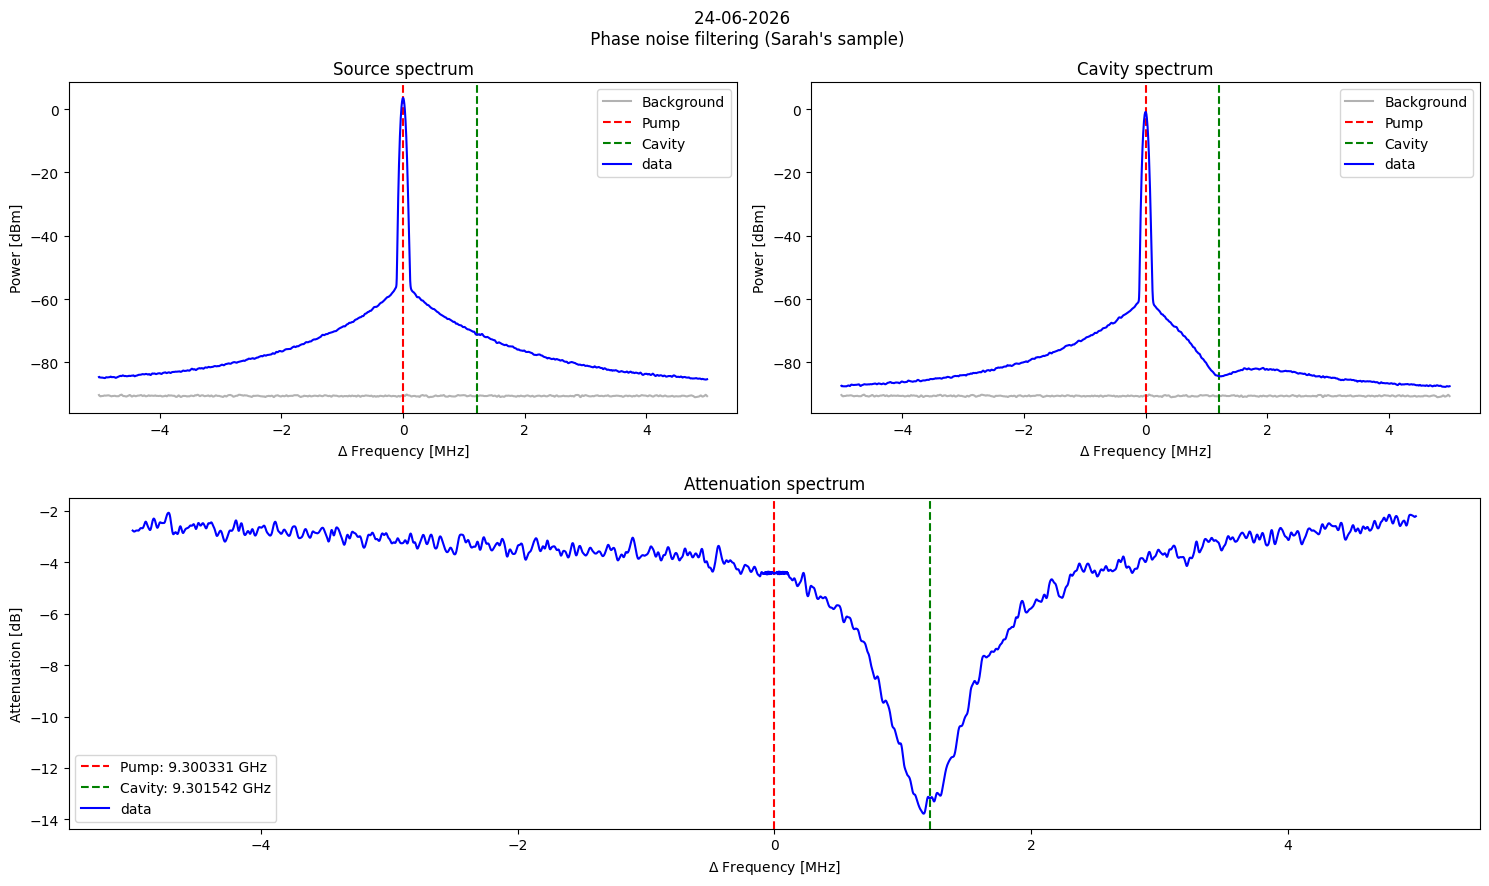

In [12]:
fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 2)

ax_source = fig.add_subplot(gs[0, 0])
ax_cavity = fig.add_subplot(gs[0, 1])
ax_att = fig.add_subplot(gs[1, :])

freq = source.freq.values
delta_freq = (freq - freq[len(freq)//2])*1e3 # MHz
dBm_background = background.spect.values
dBm_source = source.spect.values
dBm_cavity = cavity.spect.values

ymin = np.min(dBm_background) - 5
ymax = np.max(dBm_source) + 5

ax_source.plot(delta_freq, dBm_background, color='black', alpha = 0.3, label='Background')
ax_source.axvline(0, color='red', linestyle='--', label='Pump')
ax_source.axvline(fm * 1e-6, color='green', linestyle='--', label='Cavity')
ax_source.plot(delta_freq, dBm_source, color='blue', label='data')
ax_source.set_xlabel('$\Delta$ Frequency [MHz]')
ax_source.set_ylabel('Power [dBm]')
ax_source.set_ylim(ymin, ymax)
ax_source.set_title('Source spectrum')
ax_source.legend()

ax_cavity.plot(delta_freq, dBm_background, color='black', alpha = 0.3, label='Background')
ax_cavity.axvline(0, color='red', linestyle='--', label='Pump')
ax_cavity.axvline(fm * 1e-6, color='green', linestyle='--', label='Cavity')
ax_cavity.plot(delta_freq, dBm_cavity, color='blue', label='data')
ax_cavity.set_xlabel('$\Delta$ Frequency [MHz]')
ax_cavity.set_ylabel('Power [dBm]')
ax_cavity.set_ylim(ymin, ymax)
ax_cavity.set_title('Cavity spectrum')
ax_cavity.legend()

ax_att.axvline(0, color='red', linestyle='--', label=f'Pump: {(fc - fm)*1e-09:.6f} GHz')
ax_att.axvline(fm * 1e-6, color='green', linestyle='--', label=f'Cavity: {fc*1e-09:.6f} GHz')
ax_att.plot(delta_freq, dBm_cavity - dBm_source, color='blue', label='data')
ax_att.set_xlabel('$\Delta$ Frequency [MHz]')
ax_att.set_ylabel('Attenuation [dB]')
ax_att.set_title('Attenuation spectrum')
ax_att.legend()

fig.suptitle(f"24-06-2026 \n Phase noise filtering (Sarah's sample)")
fig.tight_layout()